<a href="https://colab.research.google.com/github/Ebasurtos/AHPC/blob/main/LAb2v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Usando dispositivo: cuda
GPU: Tesla T4
Cargando datasets...
Creando dataset sintético...
✓ Fake dataset creado
Intentando cargar VOCSegmentation...
✓ VOC cargado correctamente
Intentando cargar OxfordIIITPet...
✓ PET cargado correctamente

✅ Datasets listos: ['VOC', 'PET', 'FAKE']

Entrenando en VOC


Epoch 1/2: 100%|██████████| 366/366 [00:14<00:00, 24.98it/s, loss=0.609]


Epoch 1: Loss = 0.6368 | mIoU = 0.3515


Epoch 2/2: 100%|██████████| 366/366 [00:14<00:00, 24.56it/s, loss=0.711]


Epoch 2: Loss = 0.5936 | mIoU = 0.3432

Entrenando en PET


...

Epoch 2: Loss = 0.8604 | mIoU = 0.2762

Entrenando en FAKE


Epoch 1/2: 100%|██████████| 25/25 [00:03<00:00,  7.59it/s, loss=0.580]


Epoch 1: Loss = 0.7807 | mIoU = 0.2378


Epoch 2/2: 100%|██████████| 25/25 [00:02<00:00, 11.06it/s, loss=0.768]


Epoch 2: Loss = 0.6981 | mIoU = 0.2327


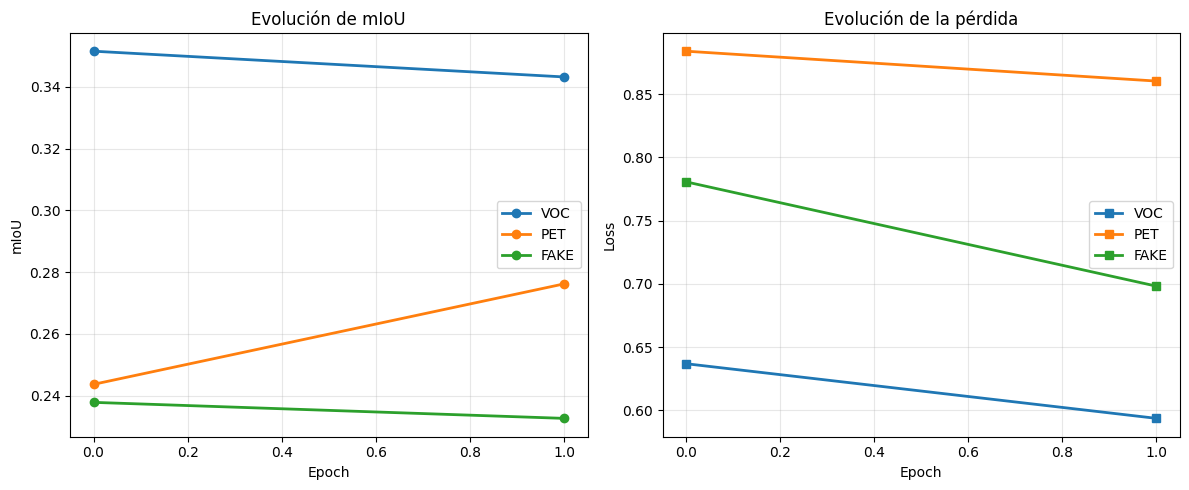


RESUMEN DE RESULTADOS
Dataset    Final Loss   Final mIoU   Best mIoU   
--------------------------------------------------
VOC        0.5936       0.3432       0.3515      
PET        0.8604       0.2762       0.2762      
FAKE       0.6981       0.2327       0.2378      

✅ Entrenamiento completado!


In [2]:
# ======================
# 1. INSTALACIÓN Y CONFIGURACIÓN
# ======================
!pip install tqdm -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os
import gc
import random
from PIL import Image

# Verificar GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Usando dispositivo: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Crear directorio para datos
data_dir = '/content/data'
os.makedirs(data_dir, exist_ok=True)

# ======================
# 2. DATASETS & TRANSFORMS
# ======================
class SegmentationTransform:
    def __init__(self, size):
        self.size = size
        self.img_transform = T.Compose([
            T.Resize(size),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        self.mask_transform = T.Compose([
            T.Resize(size, interpolation=T.InterpolationMode.NEAREST),
            T.Lambda(lambda x: torch.from_numpy(np.array(x)).long())
        ])

    def __call__(self, img, mask):
        img = self.img_transform(img)
        mask = self.mask_transform(mask)
        return img, mask

class RemapLabels:
    def __init__(self, mode='voc'):
        self.mode = mode

    def __call__(self, mask):
        if self.mode == 'pet':
            return mask - 1
        elif self.mode == 'voc':
            remapped = torch.zeros_like(mask)
            remapped[mask == 15] = 1
            remapped[(mask > 0) & (mask != 15) & (mask != 255)] = 2
            return remapped
        return mask

# ======================
# 3. DATASET SINTÉTICO
# ======================
class FakeSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, size=200, img_size=(128, 128), num_classes=3):
        self.size = size
        self.img_size = img_size
        self.num_classes = num_classes

    def __len__(self):
        return self.size

    def generate_shape_mask(self, h, w, shape_type):
        mask = torch.zeros(h, w)
        center_h, center_w = h // 2, w // 2

        if shape_type == 'circle':
            # Usar meshgrid
            y_coords = torch.arange(h)
            x_coords = torch.arange(w)
            y, x = torch.meshgrid(y_coords, x_coords, indexing='ij')
            dist_from_center = torch.sqrt((x - center_w) ** 2 + (y - center_h) ** 2)
            radius = min(h, w) // 4
            mask[dist_from_center <= radius] = 1

        elif shape_type == 'rectangle':
            rect_h, rect_w = h // 2, w // 2
            top = center_h - rect_h // 2
            bottom = center_h + rect_h // 2
            left = center_w - rect_w // 2
            right = center_w + rect_w // 2
            mask[top:bottom, left:right] = 1

        elif shape_type == 'triangle':
            for i in range(h):
                for j in range(w):
                    if i <= center_h and j >= center_w - i and j <= center_w + i:
                        mask[i, j] = 1
        return mask

    def __getitem__(self, idx):
        h, w = self.img_size
        # Imagen base con ruido
        img = torch.randn(3, h, w) * 0.5 + 0.5
        mask = torch.zeros(h, w, dtype=torch.long)

        shapes = ['circle', 'rectangle', 'triangle']

        for class_id in range(1, self.num_classes):
            shape_type = random.choice(shapes)
            shape_mask = self.generate_shape_mask(h, w, shape_type)
            mask[shape_mask == 1] = class_id

            # Colorear la forma
            color = torch.rand(3, 1, 1) * 0.8 + 0.2
            for c in range(3):
                img[c][shape_mask == 1] = color[c]

        return img, mask

# ======================
# 4. MODELO ECENET
# ======================
class FeatureReconstruction(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c//2, 1)
        self.conv2 = nn.Conv2d(c//2, c//2, 3, padding=1)
        self.out = nn.Conv2d(c, c, 1)

    def forward(self, x):
        a = self.conv1(x)
        b = self.conv2(a)
        return self.out(torch.cat([a, b], 1))

class ECE(nn.Module):
    def __init__(self, c, nc):
        super().__init__()
        self.conv = nn.Conv2d(c, nc, 1)
        self.fc = nn.Linear(nc, c)

    def forward(self, x):
        m = self.conv(x)
        p = F.adaptive_avg_pool2d(m, (1, 1)).view(x.size(0), -1)
        e = self.fc(p)
        return e, m

class SAU(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.attn = nn.MultiheadAttention(c, 4, batch_first=True)

    def forward(self, f, e):
        B, C, H, W = f.shape
        f_flat = f.view(B, C, -1).permute(0, 2, 1)
        e_expanded = e.unsqueeze(1).expand(-1, H*W, -1)
        out, _ = self.attn(f_flat, e_expanded, e_expanded)
        return out.permute(0, 2, 1).view(B, C, H, W)

class ECENet(nn.Module):
    def __init__(self, nc=3):
        super().__init__()
        base = torchvision.models.resnet18(weights="DEFAULT")
        self.backbone = nn.Sequential(*list(base.children())[:-2])
        self.fr = FeatureReconstruction(512)
        self.ece = ECE(512, nc)
        self.sau = SAU(512)
        self.dec = nn.Conv2d(512, nc, 1)

    def forward(self, x):
        f = self.backbone(x)
        f = self.fr(f)
        e, m = self.ece(f)
        f = self.sau(f, e)
        out = self.dec(f)
        return F.interpolate(out, size=(128, 128), mode='bilinear', align_corners=False), m

# ======================
# 5. MÉTRICAS
# ======================
def compute_mIoU(pred, target, num_classes=3):
    pred = torch.argmax(pred, 1)
    ious = []
    for cls in range(num_classes):
        inter = ((pred == cls) & (target == cls)).sum().item()
        union = ((pred == cls) | (target == cls)).sum().item()
        if union > 0:
            ious.append(inter / union)
    return np.mean(ious) if ious else 0

# ======================
# 6. PREPARACIÓN DE DATOS
# ======================
size = (128, 128)
trans_voc = SegmentationTransform(size)
trans_pet = SegmentationTransform(size)

print("Cargando datasets...")

# Dataset sintético (siempre disponible)
print("Creando dataset sintético...")
fake_seg = FakeSegmentationDataset(size=100, img_size=size, num_classes=3)
print("✓ Fake dataset creado")

# Intentar cargar datasets reales (opcional)
voc_raw = None
pet_raw = None

try:
    print("Intentando cargar VOCSegmentation...")
    voc_raw = torchvision.datasets.VOCSegmentation(
        root=data_dir, year='2012', image_set='train',
        download=True, transforms=trans_voc
    )
    print("✓ VOC cargado correctamente")
except Exception as e:
    print(f"⚠ VOC no disponible: {e}")

try:
    print("Intentando cargar OxfordIIITPet...")
    pet_raw = torchvision.datasets.OxfordIIITPet(
        root=data_dir, split='trainval', download=True,
        target_types='segmentation', transforms=trans_pet
    )
    print("✓ PET cargado correctamente")
except Exception as e:
    print(f"⚠ PET no disponible: {e}")

class RemappedDataset(torch.utils.data.Dataset):
    def __init__(self, base, mode):
        self.base = base
        self.remap = RemapLabels(mode)
        self.valid = base is not None

    def __len__(self):
        return len(self.base) if self.valid else 0

    def __getitem__(self, idx):
        img, mask = self.base[idx]
        if len(mask.shape) == 3:
            mask = mask.squeeze(0)
        return img, self.remap(mask)

# Crear dataloaders
loaders = {}
if voc_raw is not None:
    loaders["VOC"] = DataLoader(RemappedDataset(voc_raw, 'voc'), batch_size=4, shuffle=True)
if pet_raw is not None:
    loaders["PET"] = DataLoader(RemappedDataset(pet_raw, 'pet'), batch_size=4, shuffle=True)
loaders["FAKE"] = DataLoader(fake_seg, batch_size=4, shuffle=True)

print(f"\n✅ Datasets listos: {list(loaders.keys())}")

# ======================
# 7. ENTRENAMIENTO
# ======================
history = {}
all_results = {}

for name, loader in loaders.items():
    print(f"\n{'='*50}")
    print(f"Entrenando en {name}")
    print(f"{'='*50}")

    # Limpiar memoria
    if device == 'cuda':
        torch.cuda.empty_cache()
        gc.collect()

    model = ECENet(3).to(device)
    opt = torch.optim.Adam(model.parameters(), 1e-4)
    loss_fn = nn.CrossEntropyLoss()

    losses, ious = [], []
    epochs = 2

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")

        for x, y in progress_bar:
            x, y = x.to(device), y.to(device)

            if len(y.shape) == 3:
                y = y.long()

            p, _ = model(x)
            loss = loss_fn(p, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.3f}'})

        # Evaluación
        model.eval()
        all_ious = []

        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                if len(y.shape) == 3:
                    y = y.long()
                p, _ = model(x)
                all_ious.append(compute_mIoU(p, y))

        avg_iou = np.mean(all_ious)
        avg_loss = total_loss / len(loader)
        losses.append(avg_loss)
        ious.append(avg_iou)

        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f} | mIoU = {avg_iou:.4f}")

    history[name] = {"loss": losses, "miou": ious}
    all_results[name] = {
        "final_loss": losses[-1],
        "final_miou": ious[-1],
        "best_miou": max(ious)
    }

    del model
    if device == 'cuda':
        torch.cuda.empty_cache()

# ======================
# 8. RESULTADOS
# ======================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for k, v in history.items():
    plt.plot(v['miou'], marker='o', label=k, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.title('Evolución de mIoU')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for k, v in history.items():
    plt.plot(v['loss'], marker='s', label=k, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Evolución de la pérdida')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("RESUMEN DE RESULTADOS")
print("="*50)
print(f"{'Dataset':<10} {'Final Loss':<12} {'Final mIoU':<12} {'Best mIoU':<12}")
print("-"*50)
for name, results in all_results.items():
    print(f"{name:<10} {results['final_loss']:<12.4f} {results['final_miou']:<12.4f} {results['best_miou']:<12.4f}")

print("\n✅ Entrenamiento completado!")